# Customer Segmentation & Marketing Campaign Analytics
## Phase 3 — Customer Segmentation

**Goal of this notebook.** Group the 45,211 customers into a small number of segments using
**K-means clustering**, an unsupervised method that finds natural groupings in data with no target
column involved. The target (`subscribed`) is not used to build the segments — only afterward, in
Phase 4, to check whether the segments turn out to differ in how often people respond.

**What goes into the clustering, and what doesn't.** The features are a customer's **engagement
history**: how recently they were last contacted, how often, and what happened last time
(recency / frequency / prior outcome — the same idea behind the "RFM" segmentation banks and
retailers have used for decades). **Demographics (age, job, education) and financial status
(balance, existing loans) are deliberately left out of the clustering itself** and used afterward,
in Section 5, to describe who ended up in each segment. Section 4 shows why: tested empirically,
adding them to the clustering made the segments *less* distinct, not more.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from src.db import connect, exec_sql_file

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

con = connect()

## 1. Engineering the behavioral features

`sql/13_engineer_behavioral_features.sql` turns `pdays`, `campaign`, `previous` and `poutcome`
into the six columns the clustering will actually use.

In [2]:
exec_sql_file(con, "13_engineer_behavioral_features.sql")
FEATURES = ["recency_days", "campaign_capped", "previous_capped",
            "poutcome_failure", "poutcome_other", "poutcome_success"]
bank = con.execute("SELECT * FROM bank_features").fetchdf()
bank[["customer_id", "pdays", "campaign", "previous", "poutcome"] + FEATURES].head(3)

,customer_id,pdays,campaign,previous,poutcome,recency_days,campaign_capped,previous_capped,poutcome_failure,poutcome_other,poutcome_success
0,1,-1,1,0,unknown,999,1,0,0,0,0
1,2,-1,1,0,unknown,999,1,0,0,0,0
2,3,-1,1,0,unknown,999,1,0,0,0,0


**What each feature means, and why it needed engineering rather than using the raw column:**

- **`recency_days`** — days since the customer's last contact in a *previous* campaign. The raw
  column, `pdays`, uses **-1** to mean "never contacted before". Left as -1, a clustering
  algorithm comparing numeric distances would read that as *close to zero*, i.e. "contacted very
  recently" — the opposite of what it means. `recency_days` replaces -1 with **999**, a value
  worse than the longest real gap in the data (871 days), so "never contacted" correctly lands at
  the far end of the recency scale.
- **`campaign_capped` / `previous_capped`** — the number of contacts this campaign, and before it.
  Both have a long tail of rare extreme values (up to 63 and 275 respectively). Values are capped
  at 10, affecting 2.6% and 0.7% of customers, so a handful of extreme rows can't dominate the
  distance calculations K-means relies on.
- **`poutcome_failure` / `poutcome_other` / `poutcome_success`** — one flag per possible outcome
  of a previous campaign, except `unknown` (mostly "never contacted before" — see notebook 1,
  Section 5), which is left as the reference case where all three flags are 0.

## 2. Scaling

`recency_days` ranges up to 999; the `poutcome_*` flags are just 0 or 1. Left unscaled, K-means
(which measures straight-line distance between customers) would let `recency_days` dominate the
outcome almost by itself, simply because its numbers are bigger, not because it matters more.
**`StandardScaler`** rescales every feature to the same footing: it subtracts each column's
average and divides by its spread, so every feature contributes on equal terms.

In [3]:
X = bank[FEATURES].astype(float).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=FEATURES).describe().loc[["mean", "std"]].round(2)

,recency_days,campaign_capped,previous_capped,poutcome_failure,poutcome_other,poutcome_success
mean,-0.0,0.0,0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0


After scaling, every feature has a mean of 0 and a standard deviation of 1 — on equal footing for
the clustering that follows.

## 3. Choosing the number of segments: the elbow method and the silhouette score

K-means needs to be told how many groups (*k*) to find; it doesn't discover that number on its
own. Two standard tools help pick it, used together below:

- **The elbow method** plots *inertia* (how tightly packed each cluster is — lower is tighter) against
  k. Inertia always falls as k rises (more clusters can always fit the data more snugly), but it
  falls in big steps at first and then flattens out. The "elbow" — where the drop stops being
  worth an extra cluster — is a reasonable choice.
- **The silhouette score** measures, for every customer, how much closer they are to their own
  cluster's center than to the next-nearest one, averaged across everyone. It ranges from -1 to 1;
  higher means the clusters are more clearly separated from each other. Unlike inertia, it doesn't
  always favor more clusters, so it's a useful second opinion. (Computed on a fixed random sample
  of 5,000 customers — the full calculation over all pairs of 45,211 customers is
  needlessly slow for a diagnostic plot.)

In [4]:
inertias, silhouettes = {}, {}
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(X_scaled), 5000, replace=False)

for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias[k] = km.inertia_
    silhouettes[k] = silhouette_score(X_scaled[sample_idx], km.labels_[sample_idx])

diag = pd.DataFrame({"inertia": inertias, "silhouette_score": silhouettes})
diag.round(4)

,inertia,silhouette_score
2,161218.9500,0.7012
3,113205.5810,0.7377
4,65386.9030,0.7666
5,36403.5211,0.7237
6,29271.0198,0.7212
7,24461.6062,0.7197
8,18434.5328,0.6804


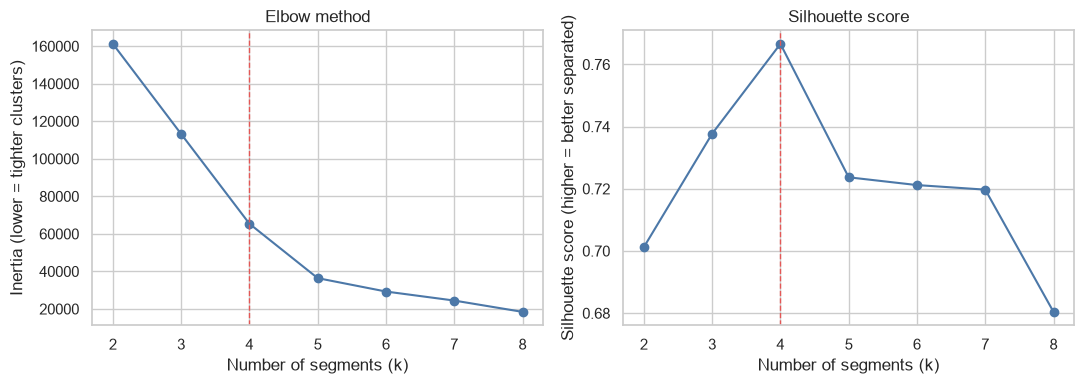

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(diag.index, diag.inertia, marker="o", color="#4C78A8")
axes[0].set_xlabel("Number of segments (k)"); axes[0].set_ylabel("Inertia (lower = tighter clusters)")
axes[0].set_title("Elbow method")
axes[0].axvline(4, color="#E45756", ls="--", lw=1)

axes[1].plot(diag.index, diag.silhouette_score, marker="o", color="#4C78A8")
axes[1].set_xlabel("Number of segments (k)"); axes[1].set_ylabel("Silhouette score (higher = better separated)")
axes[1].set_title("Silhouette score")
axes[1].axvline(4, color="#E45756", ls="--", lw=1)

plt.tight_layout()
plt.savefig("../reports/03_elbow_and_silhouette.png", dpi=150)
plt.show()

**What this shows.** Inertia drops sharply through k=4 and then flattens — the "elbow." The
silhouette score **peaks at k=4 (0.767)** and falls at every k above that. Both tools agree:
**k = 4** is the choice, not a compromise between conflicting signals.

## 4. A judgment call, tested rather than assumed: should demographics and financial status
   also drive the clustering?

This notebook clusters on behavioral features and profiles with demographics
afterward. Before accepting that split, it's worth checking whether adding demographics and
financial status (age, balance, existing loans) into the clustering itself would produce sharper
segments. The same elbow-and-silhouette process, run on an 11-feature set (the 6 behavioral
features above, plus `age`, `balance`, `has_housing_loan`, `has_personal_loan` and
`credit_in_default`), answers that.

In [6]:
EXTRA = ["age", "balance", "has_housing_loan", "has_personal_loan", "credit_in_default"]
X_wide = bank[FEATURES + EXTRA].astype(float).values
X_wide_scaled = StandardScaler().fit_transform(X_wide)

wide_silhouettes = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_wide_scaled)
    wide_silhouettes[k] = silhouette_score(X_wide_scaled[sample_idx], km.labels_[sample_idx])

compare = pd.DataFrame({
    "behavioral features only": diag.silhouette_score,
    "+ demographics & financial status": pd.Series(wide_silhouettes),
})
compare.round(3)

,behavioral features only,+ demographics & financial status
2,0.701,0.447
3,0.738,0.459
4,0.767,0.259
5,0.724,0.295
6,0.721,0.314
7,0.720,0.362
8,0.680,0.384


**What this shows.** Adding demographics and financial status **lowers the silhouette score at
every value of k** — its best case (k=3, 0.459) is well below the behavioral-only best (k=4,
0.767). Demographics and financial status vary only mildly across customers with similar
engagement histories, so folding them into the clustering mostly adds noise, diluting otherwise
clear groups rather than sharpening them. **This confirms that split was the right
call, backed by evidence rather than assumed: engagement history *defines* the
segments, and demographics *describe* them.** The rest of this notebook clusters on the six
behavioral features only.

## 5. Fitting the final model and naming the segments

In [7]:
final_km = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
bank["segment_id"] = final_km.labels_

segment_feature_profile = bank.groupby("segment_id")[FEATURES].mean().round(1)
segment_feature_profile["n_customers"] = bank.groupby("segment_id").size()
segment_feature_profile["pct_of_customers"] = (segment_feature_profile.n_customers / len(bank) * 100).round(1)
segment_feature_profile

,recency_days,campaign_capped,previous_capped,poutcome_failure,poutcome_other,poutcome_success,n_customers,pct_of_customers
segment_id,,,,,,,,
0,998.9,2.7,0.0,0.0,0.0,0.0,36957,81.7
1,241.6,2.0,2.7,1.0,0.0,0.0,4903,10.8
2,229.7,2.4,3.4,0.0,1.0,0.0,1840,4.1
3,163.3,1.8,3.0,0.0,0.0,1.0,1511,3.3


**Reading the four segments off their engagement-history averages:**

| segment_id | recency_days | prior outcome | What it means |
|---|---|---|---|
| the largest one | ~999 (never contacted) | none | first-time contacts |
| one | ~242 days ago | failure | said no last time |
| one | ~230 days ago | other | an ambiguous/partial prior outcome |
| the smallest one | ~163 days ago | success | said yes last time |

Named for what they are:

In [8]:
SEGMENT_NAMES = {}
for sid, row in bank.groupby("segment_id")[["poutcome_success", "poutcome_failure", "poutcome_other", "recency_days"]].mean().iterrows():
    if row.poutcome_success > 0.5:
        SEGMENT_NAMES[sid] = "Warm: Past Success"
    elif row.poutcome_failure > 0.5:
        SEGMENT_NAMES[sid] = "Warm: Past No"
    elif row.poutcome_other > 0.5:
        SEGMENT_NAMES[sid] = "Warm: Past Mixed Outcome"
    else:
        SEGMENT_NAMES[sid] = "Cold: Never Contacted"

bank["segment_name"] = bank.segment_id.map(SEGMENT_NAMES)
bank.groupby("segment_name").size().sort_values(ascending=False)

segment_name
Cold: Never Contacted       36957
Warm: Past No                4903
Warm: Past Mixed Outcome     1840
Warm: Past Success           1511
dtype: int64

## 6. Profiling each segment: demographics, financial status, and contact history

Now demographics, financial status and contact context — none of which were used to build the
segments — are brought in to describe who is actually in each one.

In [9]:
profile = bank.groupby("segment_name").agg(
    n_customers=("customer_id", "size"),
    avg_age=("age", "mean"),
    median_balance=("balance", "median"),
    pct_housing_loan=("has_housing_loan", "mean"),
    pct_personal_loan=("has_personal_loan", "mean"),
    pct_tertiary_educated=("education", lambda s: (s == "tertiary").mean()),
    pct_contact_unknown=("contact", lambda s: (s == "unknown").mean()),
).round(3)
profile["pct_of_customers"] = (profile.n_customers / len(bank) * 100).round(1)
for c in ["pct_housing_loan", "pct_personal_loan", "pct_tertiary_educated", "pct_contact_unknown"]:
    profile[c] = (profile[c] * 100).round(1)
profile = profile[["n_customers", "pct_of_customers", "avg_age", "median_balance",
                    "pct_housing_loan", "pct_personal_loan", "pct_tertiary_educated", "pct_contact_unknown"]]
profile.sort_values("n_customers", ascending=False)

,n_customers,pct_of_customers,avg_age,median_balance,pct_housing_loan,pct_personal_loan,pct_tertiary_educated,pct_contact_unknown
segment_name,,,,,,,,
Cold: Never Contacted,36957,81.7,40.932,414.0,54.1,16.6,28.8,35.0
Warm: Past No,4903,10.8,40.785,549.0,70.8,15.8,30.5,0.6
Warm: Past Mixed Outcome,1840,4.1,39.752,570.0,65.2,14.4,29.6,1.5
Warm: Past Success,1511,3.3,42.965,920.0,31.2,5.4,41.2,0.8


**What this shows.**

- **"Warm: Past Success" (1,511 customers, 3.3%) stands apart on every measure**, not just
  engagement: a €920 median balance (roughly double the other segments' €414-570), the lowest
  housing-loan rate (31%, versus 54-71% elsewhere), the lowest personal-loan rate (5%, versus
  14-17%), the most tertiary education (41%), and by far the best phone-number data quality (0.8%
  "unknown" contact type, versus 35% for the "Cold" segment). This segment is not just people who
  said yes before — they look like a financially stronger, more reachable group in general.
- **"Cold: Never Contacted" (36,957 customers, 81.7%) has the worst contact-channel data**: 35% of
  this segment's phone numbers are on file as "unknown" type, versus under 2% for any warm
  segment. Some of this segment's low response rate may be a reachability problem, not only a
  persuasion problem.
- **The three non-"Past Success" segments look demographically similar to each other**
  (age 39.8-40.9, education mix within a few points, job mix nearly identical) — age, job and
  education mainly separate "Past Success" from everyone else, they don't meaningfully separate
  the other three segments from one another. The real differences between those three are entirely
  in their engagement history, which is exactly what defined them.

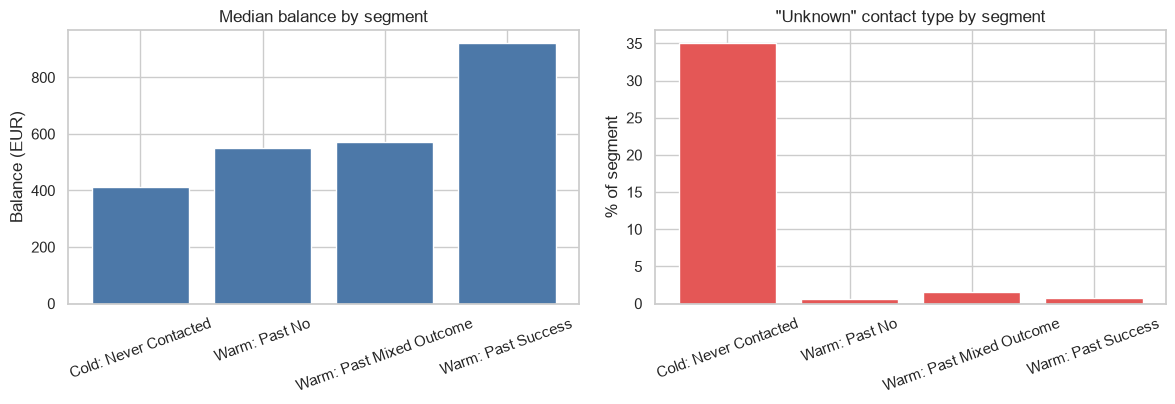

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
order = profile.sort_values("n_customers", ascending=False).index
axes[0].bar(order, profile.loc[order, "median_balance"], color="#4C78A8")
axes[0].set_title("Median balance by segment"); axes[0].set_ylabel("Balance (EUR)")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(order, profile.loc[order, "pct_contact_unknown"], color="#E45756")
axes[1].set_title('"Unknown" contact type by segment'); axes[1].set_ylabel("% of segment")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../reports/03_segment_profile.png", dpi=150)
plt.show()

## 7. Saving the segments

Segment assignments are written back to the database as `customer_segments`, keyed by
`customer_id`, so Phase 4 (and the dashboard) can bring in segment membership with a plain SQL
join instead of re-running the clustering.

In [11]:
segments_out = bank[["customer_id", "segment_id", "segment_name"]]
con.register("segments_out", segments_out)
con.execute("CREATE OR REPLACE TABLE customer_segments AS SELECT * FROM segments_out")
con.execute("SELECT segment_name, COUNT(*) FROM customer_segments GROUP BY 1 ORDER BY 2 DESC").fetchdf()

,segment_name,count_star()
0,Cold: Never Contacted,36957
1,Warm: Past No,4903
2,Warm: Past Mixed Outcome,1840
3,Warm: Past Success,1511


## Phase 3 summary (plain English)

- Customers were grouped by **engagement history alone** — how recently and how often they've
  been contacted, and what happened last time — not by who they are. **k = 4** was chosen because
  the elbow method and the silhouette score (which peaks at 0.767 for k=4) agree.
- **Demographics and financial status were tested as clustering inputs and made the segments
  worse** (best silhouette 0.459 at k=3, well below 0.767), confirming they belong in the
  *profile* of each segment rather than its *definition*.
- **The four segments:**
  1. **Cold: Never Contacted** (36,957 / 81.7%) — no prior campaign history; the worst
     contact-data quality (35% "unknown" phone type).
  2. **Warm: Past No** (4,903 / 10.8%) — declined a previous campaign, ~242 days ago on average.
  3. **Warm: Past Mixed Outcome** (1,840 / 4.1%) — an ambiguous prior result, ~230 days ago.
  4. **Warm: Past Success** (1,511 / 3.3%) — said yes before, ~163 days ago on average, and
     financially distinct from the rest: higher balance, lower debt, more education, and by far
     the best contact-data quality.
- Segment assignments are saved to `customer_segments` in the shared DuckDB database for Phase 4
  to build on.